## План анализа данных (data mining):


1.   Загрузить данные для обучения
2.  Обработать данные перед обучением модели
3.   Обучить модель на обучающей выборке
4.   Загрузить и предобработать данные для тестирования
5.   Провалидировать модель на тестовой выборке
6.   Проанализировать важность признаков и не забыть про постановку задачи




Шаг 1

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd # загружаем библиотеку и для простоты обращения в коде называем её сокращенно pd
import matplotlib.pyplot as plt # загружаем библиотеку и для простоты обращения в коде называем её сокращенно plt
# указываем, чтобы картинки отображались прямо в ноутбуке
%matplotlib inline

In [1]:
%%capture
!wget https://www.dropbox.com/s/afwb0tnqm9izxha/predict_house_price_training_data.xlsx
!wget https://www.dropbox.com/s/sur2avqf4n5f4az/predict_house_price_test_data.xlsx

In [4]:
training_data = pd.read_excel('predict_house_price_training_data.xlsx') # загружаем таблицу в переменную training_data
training_data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,830000,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,385000,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,610000,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,550000,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,1300000,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [5]:
training_data.shape

(15129, 16)

Шаг 2

In [6]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15129 entries, 0 to 15128
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         15129 non-null  int64  
 1   Спальни              15129 non-null  int64  
 2   Ванные               15129 non-null  float64
 3   Жилая площадь        15129 non-null  int64  
 4   Общая площадь        15129 non-null  int64  
 5   Количество этажей    15129 non-null  float64
 6   Вид на воду          15129 non-null  int64  
 7   Просмотрены ранее    15129 non-null  int64  
 8   Состояние            15129 non-null  int64  
 9   Оценка риелтора      15129 non-null  int64  
 10  Площадь без подвала  15129 non-null  int64  
 11  Площадь подвала      15129 non-null  int64  
 12  Год постройки        15129 non-null  int64  
 13  Год реновации        15129 non-null  int64  
 14  Широта               15129 non-null  float64
 15  Долгота              15129 non-null 

In [13]:
target_variable_name = 'Целевая.Цена'

training_values = training_data[target_variable_name]

training_points = training_data.drop(target_variable_name, axis=1)

training_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [14]:
training_points.shape

(15129, 15)

Шаг 3

In [16]:
from sklearn import linear_model

In [17]:
linear_regression_model = linear_model.LinearRegression() # создаем модель

linear_regression_model

LinearRegression()

In [18]:
linear_regression_model.fit(training_points, training_values)

LinearRegression()

ЗАДНИЕ 3.5

In [20]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [21]:
features = np.array(training_points, dtype=np.float64)
target = np.array(training_values, dtype=np.float64)
target

array([ 830000.,  385000.,  610000., ..., 1580000.,  339900.,  430000.])

In [22]:
num_samples, num_features = features.shape

In [25]:
scaler_features = StandardScaler()
features_scaled = scaler_features.fit_transform(features)

scaler_target = StandardScaler()
target_scaled = scaler_target.fit_transform(target.reshape(-1, 1)).flatten()

In [28]:
batch_size = 64
max_epochs = 500
learning_rate = 0.01
lambda_l1 = 0.001
lambda_l2 = 0.001
tolerance  = 1e-4

In [27]:
weights = np.zeros(num_features)
bias = 0.0
loss_values = []

In [29]:
random_generator = np.random.default_rng(seed=42)

In [35]:
for epoch in range(max_epochs):
    shuffled_indices = random_generator.permutation(num_samples)

    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = shuffled_indices[start_idx:end_idx]

        features_batch = features_scaled[batch_indices]
        target_batch = target_scaled[batch_indices]

        predictions_batch = features_batch @ weights + bias

        errors = predictions_batch - target_batch
        batch_size_current = len(target_batch)

        gradient_weights = (1 / batch_size_current) * (features_batch.T @ errors)

        gradient_weights += lambda_l2 * weights
        gradient_weights += lambda_l1 * np.sign(weights)

        gradient_bias = errors.mean()

        weights -= learning_rate * gradient_weights
        bias -= learning_rate * gradient_bias

    if epoch % 50 == 0 or epoch == max_epochs - 1:

        all_predictions = features_scaled @ weights + bias
        mse = np.mean((all_predictions - target_scaled) ** 2)

        regularization = (lambda_l2 / 2) * np.sum(weights ** 2) + lambda_l1 * np.sum(np.abs(weights))

        current_loss = mse + regularization
        loss_values.append(current_loss)

        print(f"Эпоха {epoch}, Loss: {current_loss:.6f}")

        if epoch > 0 and len(loss_values) > 1:
            loss_change = abs(loss_values[-2] - current_loss)
            if loss_change < tolerance:
                print(f"Досрочная остановка на эпохе {epoch}")
                break


Эпоха 0, Loss: 0.311018
Эпоха 50, Loss: 0.312930
Эпоха 100, Loss: 0.312390
Эпоха 150, Loss: 0.312213
Эпоха 200, Loss: 0.311225
Эпоха 250, Loss: 0.311067
Эпоха 300, Loss: 0.313131
Эпоха 350, Loss: 0.311352
Эпоха 400, Loss: 0.312366
Эпоха 450, Loss: 0.311058
Эпоха 499, Loss: 0.311349


Шаг 4

In [37]:
test_data = pd.read_excel('predict_house_price_test_data.xlsx')
test_data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,260000,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,734500,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,325000,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,1990000,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,315000,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


In [38]:
test_data.shape

(6484, 16)

In [39]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         6484 non-null   int64  
 1   Спальни              6484 non-null   int64  
 2   Ванные               6484 non-null   float64
 3   Жилая площадь        6484 non-null   int64  
 4   Общая площадь        6484 non-null   int64  
 5   Количество этажей    6484 non-null   float64
 6   Вид на воду          6484 non-null   int64  
 7   Просмотрены ранее    6484 non-null   int64  
 8   Состояние            6484 non-null   int64  
 9   Оценка риелтора      6484 non-null   int64  
 10  Площадь без подвала  6484 non-null   int64  
 11  Площадь подвала      6484 non-null   int64  
 12  Год постройки        6484 non-null   int64  
 13  Год реновации        6484 non-null   int64  
 14  Широта               6484 non-null   float64
 15  Долгота              6484 non-null   f

In [41]:
test_values = test_data[target_variable_name]
test_points = test_data.drop(target_variable_name, axis=1)
test_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


In [42]:
test_points.shape

(6484, 15)

Шаг 5

In [46]:
test_predictions_linear = linear_regression_model.predict(test_points)

In [47]:
X_test_scaled = scaler_features.transform(test_points)
y_pred_scaled = X_test_scaled @ weights + bias

test_predictions_custom = scaler_target.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [49]:
mean_absolute_error_linear_model = mean_absolute_error(test_values, test_predictions_linear)
mean_squared_error_linear_model = mean_squared_error(test_values, test_predictions_linear)

In [51]:
mean_absolute_error_custom = mean_absolute_error(test_values, test_predictions_custom)
mean_squared_error_custom = mean_squared_error(test_values, test_predictions_custom)

In [55]:
print("\nSklearn модель:")
print(f"MAE: {mean_absolute_error_linear_model:.2f}")
print(f"MSE: {mean_squared_error_linear_model:.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error_linear_model):.2f}")

print("\nРучная модель:")
print(f"MAE: {mean_absolute_error_custom:.2f}")
print(f"MSE: {mean_squared_error_custom:.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error_custom):.2f}")

if mean_squared_error_custom < mean_squared_error_linear_model:
    print(f"Ошибка ручной модели {mean_squared_error_custom:.2f} < ошибки Sklearn модели {mean_squared_error_linear_model:.2f} => ручная модель лучше")
else:
    print(f"Ошибка ручной модели {mean_squared_error_custom:.2f} > ошибки Sklearn модели {mean_squared_error_linear_model:.2f} => Sklearn модель лучше")


Sklearn модель:
MAE: 126852.51
MSE: 40756843765.10
RMSE: 201883.24

Ручная модель:
MAE: 125508.93
MSE: 40762405640.26
RMSE: 201897.02
Ошибка ручной модели 40762405640.26 > ошибки Sklearn модели 40756843765.10 => Sklearn модель лучше


Шаг 6

In [56]:
training_points.head(10)

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407
5,3,2.25,2300,9914,2.0,0,0,4,8,2300,0,1980,0,47.5677,-122.086
6,3,2.50,2770,8820,1.0,0,0,3,7,1900,870,1980,2004,47.3685,-122.048
7,2,1.75,1650,7500,1.0,0,0,4,7,1000,650,1959,0,47.6871,-122.207
8,1,1.00,580,1799,1.0,0,0,3,7,580,0,1908,2005,47.6829,-122.375
9,2,1.00,900,3400,1.0,0,0,5,6,900,0,1905,0,47.5269,-122.314


In [57]:
training_points['Год реновации'].value_counts()

,count
Год реновации,
0,14490
2014,63
2013,31
2000,28
2003,24
...,...
1950,1
1954,1
1946,1


In [58]:
feature_names = training_points.columns
feature_importance = pd.DataFrame({
    'Название признака': feature_names,
    'Важность признака': np.abs(weights)
}).sort_values('Важность признака', ascending=False)

feature_importance

,Название признака,Важность признака
2,Жилая площадь,0.353525
8,Оценка риелтора,0.315233
13,Широта,0.216369
11,Год постройки,0.192513
5,Вид на воду,0.144618
9,Площадь без подвала,0.105075
6,Просмотрены ранее,0.104465
1,Ванные,0.082151
0,Спальни,0.081817
7,Состояние,0.057089


In [67]:
results_df = pd.DataFrame({
    'Фактическая_цена': test_values,
    'Предсказанная_цена': test_predictions_linear,
    'Разница': test_values - test_predictions_linear
})

results_df['Отклонение_процент'] = (results_df['Разница'] / results_df['Фактическая_цена']) * 100

results_df

,Фактическая_цена,Предсказанная_цена,Разница,Отклонение_процент
0,260000,2.046260e+05,55374.036204,21.297706
1,734500,9.845655e+05,-250065.478964,-34.045674
2,325000,4.396560e+05,-114655.978659,-35.278763
3,1990000,1.037046e+06,952954.375081,47.887155
4,315000,2.359235e+05,79076.497777,25.103650
...,...,...,...,...
6479,600000,8.846697e+05,-284669.658799,-47.444943
6480,435000,3.377973e+05,97202.687531,22.345445
6481,1500000,1.050230e+06,449770.037958,29.984669
6482,304999,3.064988e+05,-1499.764380,-0.491728


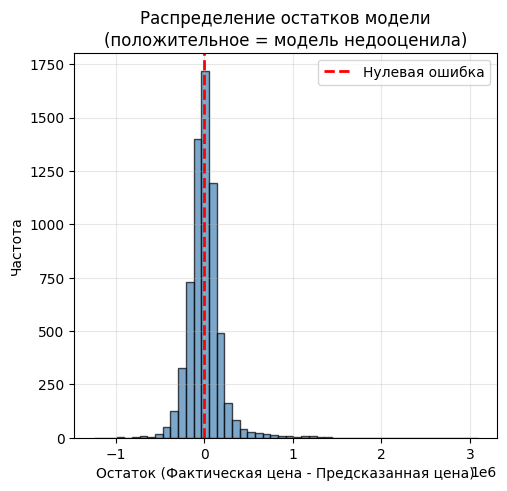

In [66]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(results_df['Разница'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
plt.xlabel('Остаток (Фактическая цена - Предсказанная цена)')
plt.ylabel('Частота')
plt.title('Распределение остатков модели\n(положительное = модель недооценила)')
plt.legend()
plt.grid(True, alpha=0.3)